# Fertilizer Prediction Using Standard Normalization, Stacking, and Blending


In [36]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

print('Libraries imported successfully.')

Libraries imported successfully.


In [37]:
# Step 1: Load dataset
df = pd.read_csv('final_processed_data.csv')

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (3100, 45)


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil_acidic soil,Soil_alkaline soil,...,Crop_pigeon peas,Crop_pomegranate,Crop_rice,Crop_rubber,Crop_sugarcane,Crop_tea,Crop_tobacco,Crop_watermelon,Crop_wheat,target_fertilizer
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,0,0,...,0,0,1,0,0,0,0,0,0,1
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,0,0,...,0,0,1,0,0,0,0,0,0,0
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,0,0,...,0,0,1,0,0,0,0,0,0,9
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,0,0,...,0,0,1,0,0,0,0,0,0,0
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,0,0,...,0,0,1,0,0,0,0,0,0,7


In [38]:
# Step 2: Check columns and missing values
print('Columns:\n', df.columns.tolist())

missing = df.isnull().sum()
print('\nMissing values per column:')
print(missing[missing > 0] if (missing > 0).any() else 'No missing values found.')

Columns:
 ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil_acidic soil', 'Soil_alkaline soil', 'Soil_loamy soil', 'Soil_neutral soil', 'Soil_peaty soil', 'Crop_adzuki beans', 'Crop_apple', 'Crop_banana', 'Crop_black gram', 'Crop_chickpea', 'Crop_coconut', 'Crop_coffee', 'Crop_cotton', 'Crop_grapes', 'Crop_ground nut', 'Crop_jute', 'Crop_kidney beans', 'Crop_lentil', 'Crop_maize', 'Crop_mango', 'Crop_millet', 'Crop_moth beans', 'Crop_mung bean', 'Crop_muskmelon', 'Crop_orange', 'Crop_papaya', 'Crop_peas', 'Crop_pigeon peas', 'Crop_pomegranate', 'Crop_rice', 'Crop_rubber', 'Crop_sugarcane', 'Crop_tea', 'Crop_tobacco', 'Crop_watermelon', 'Crop_wheat', 'target_fertilizer']

Missing values per column:
No missing values found.


In [39]:
# Step 3: Define target and normalization columns
target_col = 'target_fertilizer'

normalize_cols = [
    'Temperature', 'Moisture', 'Rainfall', 'PH',
    'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon',
]

required_cols = normalize_cols + [target_col]
missing_required = [c for c in required_cols if c not in df.columns]

if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

print('Target column:', target_col)
print('Columns selected for standard normalization:', normalize_cols)

Target column: target_fertilizer
Columns selected for standard normalization: ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']


In [40]:
from sklearn.preprocessing import MinMaxScaler

In [41]:
# Step 4: Split first, then normalize only the requested feature columns
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
# scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[normalize_cols] = scaler.fit_transform(X_train_scaled[normalize_cols])
X_test_scaled[normalize_cols] = scaler.transform(X_test_scaled[normalize_cols])

print('Scaled training sample:')
display(X_train_scaled[normalize_cols].head())

Scaled training sample:


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
2265,0.187244,-1.438228,0.115710,-0.636389,0.236616,-0.459680,-0.454882,0.325476
833,0.133855,1.320760,0.139829,0.640527,0.242675,1.579436,1.819547,-0.275988
1895,0.568204,1.183133,-0.308753,0.716478,-0.311209,1.644521,1.003580,0.340951
980,-0.619692,-0.099294,-0.495849,0.623926,-0.185805,1.872278,2.368373,-1.370017
2036,0.215064,-0.876879,-0.359042,-1.744861,-0.260392,-1.051372,-0.804779,-0.189062


In [42]:
# Quick check of mean ~ 0 and std ~ 1 after scaling on the training split
stats = pd.DataFrame({
    'mean': X_train_scaled[normalize_cols].mean(),
    'std': X_train_scaled[normalize_cols].std()
})
display(stats)

,mean,std
Temperature,3.896525e-16,1.000202
Moisture,1.812170e-16,1.000202
Rainfall,-3.151601e-17,1.000202
PH,7.628307e-16,1.000202
Nitrogen,-1.582963e-16,1.000202
Phosphorous,5.372047e-17,1.000202
Potassium,-4.369265e-17,1.000202
Carbon,-2.693186e-16,1.000202


In [43]:
# Step 5: Confirm the modeling setup
# float32 cuts memory usage roughly in half compared to float64.
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
y_train = y_train.copy()
y_test = y_test.copy()

print('X_train shape:', X_train_scaled.shape)
print('X_test shape :', X_test_scaled.shape)
print('Unique classes in target_fertilizer:', y.nunique())

X_train shape: (2480, 44)
X_test shape : (620, 44)
Unique classes in target_fertilizer: 10


## Stacking Method

In [44]:
# Step 6: Define base and meta models for stacking
# Memory-safe setup: keep multiple learners but avoid heavy parallel workers.
def build_stacking_estimators(lightweight=False):
    if lightweight:
        return [
            ('rf', RandomForestClassifier(n_estimators=80, n_jobs=1, random_state=42)),
            ('et', ExtraTreesClassifier(n_estimators=80, n_jobs=1, random_state=42)),
            ('gb', GradientBoostingClassifier(random_state=42)),
            ('gnb', GaussianNB())
        ]

    return [
        ('rf', RandomForestClassifier(n_estimators=120, n_jobs=1, random_state=42)),
        ('et', ExtraTreesClassifier(n_estimators=120, n_jobs=1, random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=9, weights='distance')),
        ('gnb', GaussianNB()),
        ('dt', DecisionTreeClassifier(max_depth=12, random_state=42))
    ]

base_estimators = build_stacking_estimators()

meta_model = LogisticRegression(max_iter=2000, multi_class='auto')

stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    stack_method='predict_proba',
    cv=3,
    n_jobs=1,
    passthrough=False
)

print(f'Stacking model initialized with {len(base_estimators)} base learners.')

Stacking model initialized with 6 base learners.


In [45]:
# Step 7: Train and evaluate stacking model
try:
    stack_model.fit(X_train_scaled, y_train)
except MemoryError:
    print('MemoryError detected. Retrying with a lighter stacking setup...')
    light_base_estimators = build_stacking_estimators(lightweight=True)
    stack_model = StackingClassifier(
        estimators=light_base_estimators,
        final_estimator=meta_model,
        stack_method='predict_proba',
        cv=3,
        n_jobs=1,
        passthrough=False
    )
    stack_model.fit(X_train_scaled, y_train)

stack_pred = stack_model.predict(X_test_scaled)
stack_acc = accuracy_score(y_test, stack_pred)
print(f'Stacking Accuracy: {stack_acc:.4f}')
print('\nStacking Classification Report:')
print(classification_report(y_test, stack_pred))

Stacking Accuracy: 0.9452

Stacking Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        31
           1       0.95      0.92      0.93        75
           2       0.99      0.93      0.96       211
           3       0.67      1.00      0.80         6
           4       0.90      0.82      0.86        11
           5       0.95      1.00      0.97        36
           6       0.95      0.85      0.89        65
           7       0.90      1.00      0.95        19
           8       1.00      1.00      1.00        31
           9       0.92      0.99      0.95       135

    accuracy                           0.95       620
   macro avg       0.91      0.95      0.92       620
weighted avg       0.95      0.95      0.95       620



## Blending Method

In [46]:
# Step 8: Create train-blend split from training data
X_base, X_blend, y_base, y_blend = train_test_split(
    X_train_scaled, y_train,
    test_size=0.3,
    random_state=42,
    stratify=y_train
)

print('Base training part :', X_base.shape)
print('Blending validation:', X_blend.shape)

Base training part : (1736, 44)
Blending validation: (744, 44)


In [47]:
# Step 9: Train base models for blending
def build_blend_models():
    return [
        RandomForestClassifier(n_estimators=120, n_jobs=1, random_state=42),
        ExtraTreesClassifier(n_estimators=120, n_jobs=1, random_state=42),
        GradientBoostingClassifier(random_state=42),
        KNeighborsClassifier(n_neighbors=9, weights='distance'),
        GaussianNB(),
        DecisionTreeClassifier(max_depth=12, random_state=42)
    ]

blend_base_models = build_blend_models()

for model in blend_base_models:
    model.fit(X_base, y_base)

print(f'Base models trained for blending: {len(blend_base_models)}')

Base models trained for blending: 6


In [48]:
# Step 10: Build meta-features using probability outputs
if 'blend_base_models' not in globals():
    print('blend_base_models not found. Re-running Step 9 setup...')
    blend_base_models = build_blend_models()
    for model in blend_base_models:
        model.fit(X_base, y_base)

blend_meta_train = np.column_stack([
    model.predict_proba(X_blend) for model in blend_base_models
]).astype(np.float32)

blend_meta_test = np.column_stack([
    model.predict_proba(X_test_scaled) for model in blend_base_models
]).astype(np.float32)

print('Meta-feature train shape:', blend_meta_train.shape)
print('Meta-feature test shape :', blend_meta_test.shape)

Meta-feature train shape: (744, 60)
Meta-feature test shape : (620, 60)


In [49]:
# Step 11: Train meta-model and evaluate blending
blend_meta_model = LogisticRegression(max_iter=2000, multi_class='auto')
blend_meta_model.fit(blend_meta_train, y_blend)

blend_pred = blend_meta_model.predict(blend_meta_test)
blend_acc = accuracy_score(y_test, blend_pred)

print(f'Blending Accuracy: {blend_acc:.4f}')
print('\nBlending Classification Report:')
print(classification_report(y_test, blend_pred))

Blending Accuracy: 0.9355

Blending Classification Report:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        31
           1       0.94      0.85      0.90        75
           2       0.97      0.94      0.95       211
           3       0.67      1.00      0.80         6
           4       0.89      0.73      0.80        11
           5       0.97      0.97      0.97        36
           6       0.93      0.86      0.90        65
           7       0.90      1.00      0.95        19
           8       1.00      1.00      1.00        31
           9       0.92      0.98      0.95       135

    accuracy                           0.94       620
   macro avg       0.90      0.93      0.91       620
weighted avg       0.94      0.94      0.94       620



Accuracy Report:


,Model,Accuracy
0,Stacking,0.945161
1,Blending,0.935484


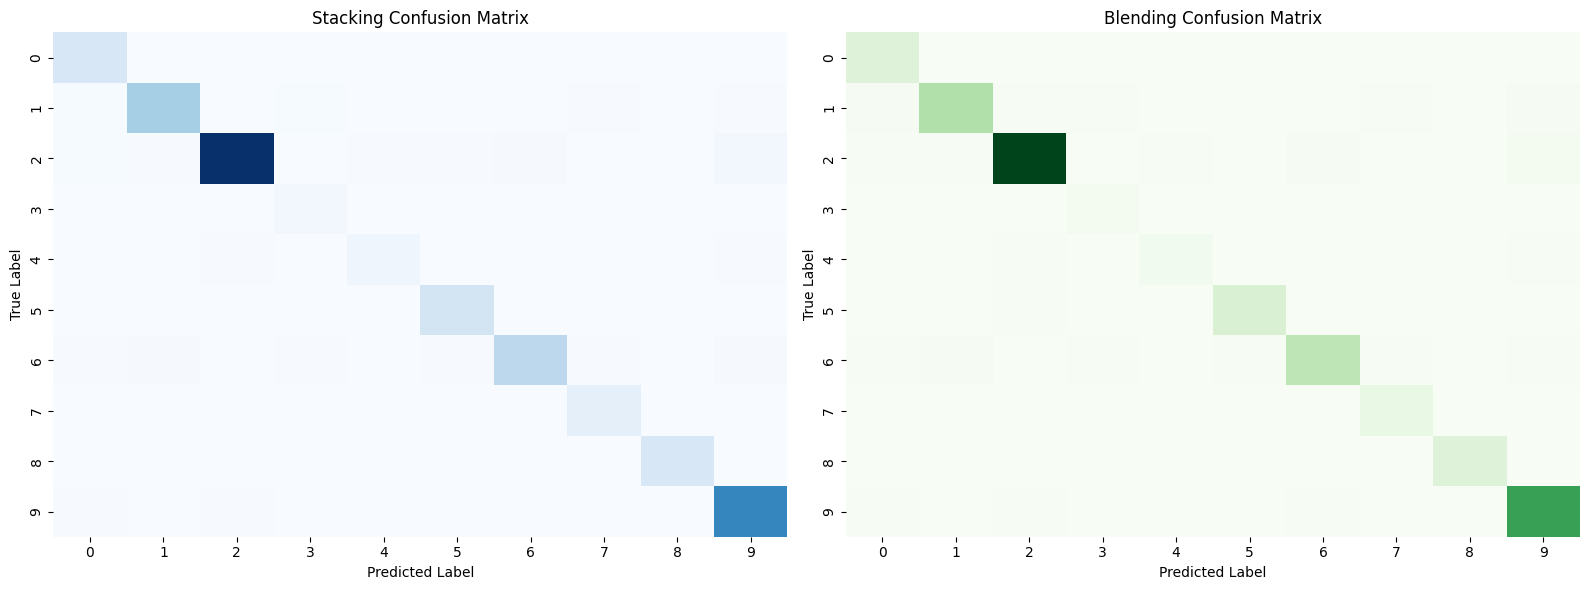

In [50]:
# Step 11.1: Accuracy report and confusion matrix (Seaborn)
accuracy_report = pd.DataFrame({
    'Model': ['Stacking', 'Blending'],
    'Accuracy': [stack_acc, blend_acc]
}).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print('Accuracy Report:')
display(accuracy_report)

stack_cm = confusion_matrix(y_test, stack_pred)
blend_cm = confusion_matrix(y_test, blend_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(stack_cm, cmap='Blues', annot=False, fmt='d', cbar=False, ax=axes[0])
axes[0].set_title('Stacking Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(blend_cm, cmap='Greens', annot=False, fmt='d', cbar=False, ax=axes[1])
axes[1].set_title('Blending Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [51]:
# Step 12: Final comparison
comparison = pd.DataFrame({
    'Method': ['Stacking', 'Blending'],
    'Accuracy': [stack_acc, blend_acc]
}).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(comparison)

best_method = comparison.loc[0, 'Method']
best_score = comparison.loc[0, 'Accuracy']
print(f'Best method on this split: {best_method} (Accuracy = {best_score:.4f})')

,Method,Accuracy
0,Stacking,0.945161
1,Blending,0.935484


Best method on this split: Stacking (Accuracy = 0.9452)


In [52]:
# # Step 12: Final comparison
# comparison = pd.DataFrame({
#     'Method': ['Stacking', 'Blending'],
#     'Accuracy': [stack_acc, blend_acc]
# }).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# display(comparison)

# best_method = comparison.loc[0, 'Method']
# best_score = comparison.loc[0, 'Accuracy']
# print(f'Best method on this split: {best_method} (Accuracy = {best_score:.4f})')